# Lab 03 - 1 #

## Pedestrian Detection using Faster R-CNN ##

In this exercise we are going to explore a classic usage of a Faster RCNN model for pedestrian detection, using the COCO format.

We are going to:
* Download pycocotools to handle image datasets that use the COCO format
* Define a dataset using the COCO format
* Download a pre-trained Faster RCNN model
* Edit the model to fine-tune it on our dataset
* Train the model on our dataset

In order to download the Penn-Fudan Database for Pedestrian Detection and Segmentation, run the following two commands:
```
!mkdir data
!cd data && wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip && unzip -o PennFudanPed.zip &> /dev/null
```

In [33]:
import os
import io
import cv2
import time
import copy
import torch
import contextlib
import torchvision
import torch.utils.data

import numpy as np
import torchvision.transforms as T

from PIL import Image
# from tqdm import tqdm
from tqdm.notebook import tqdm
from pycocotools.coco import COCO
from matplotlib import pyplot as plt
from pycocotools.cocoeval import COCOeval
from pycocotools import mask as coco_mask
from torch.utils.data.dataset import Dataset
from torch.utils.data.dataloader import DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


# Seed.
np.random.seed(66)
torch.manual_seed(66)

# Hyperparameters.
EPOCH = 3
BATCH_SIZE = 1
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device found: ", DEVICE)

Device found:  cuda


### Define the dataset (already done for you) ###

In [34]:
class PennFudanDataset(Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        # Load all image files, sorting them to ensure that they are aligned.
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # Load images and masks.
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = Image.open(img_path).convert("RGB")
        # Note that we haven't converted the mask to RGB, because each color
        # corresponds to a different instance with 0 being background.
        mask = Image.open(mask_path)
        # Convert the PIL Image into a numpy array.
        mask = np.array(mask)
        # Instances are encoded as different colors.
        obj_ids = np.unique(mask)
        # The first id is the background, so remove it.
        obj_ids = obj_ids[1:]

        # Split the color-encoded mask into a set of binary masks.
        masks = mask == obj_ids[:, None, None]

        # Get bounding box coordinates for each mask.
        num_objs = len(obj_ids)
        boxes = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])

        # Convert everything into a torch.Tensor.
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        # There is only one class.
        labels = torch.ones((num_objs,), dtype=torch.int64)
        masks = torch.as_tensor(masks, dtype=torch.uint8)

        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        # Suppose all instances are not crowd.
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img = self.transforms(img)
        else:
            img = np.asarray(img)

        return img, target

    def __len__(self):
        return len(self.imgs)

You are now required to create a dataloader and visualize a few samples of the datatet.

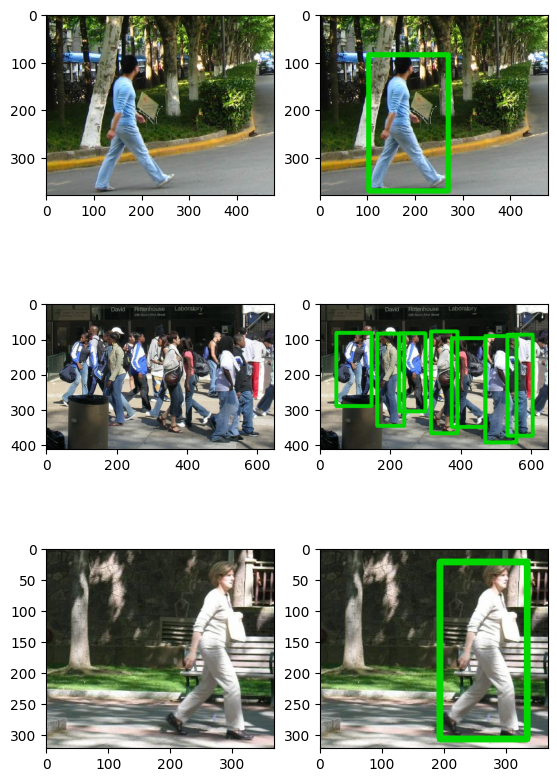

In [35]:
def show_dataset(sample_data_loader):
    plt.figure(figsize=(10,10))
    plot_samples = 3
    plot_cols = 3
    _plot_idx = 0
    for i, (image, metadata) in enumerate(sample_data_loader):
        if i >= plot_samples:
            break

        _plot_idx += 1
        plt.subplot(plot_samples, plot_cols, _plot_idx)
        image = image.squeeze().numpy()
        plt.imshow(image)

        _plot_idx += 1
        plt.subplot(plot_samples, plot_cols, _plot_idx)
        boxes = metadata["boxes"]  # 1, N, 4.
        if len(boxes.shape) == 3:
            boxes = boxes.squeeze(0)
        image_with_bbox = image.copy()
        for bbox in boxes:
            xmin, ymin, xmax, ymax = bbox
            xmin, ymin, xmax, ymax = int(xmin), int(ymin), int(xmax), int(ymax)
            pt1 = (xmin, ymin)
            pt2 = (xmax, ymax)
            cv2.rectangle(image_with_bbox, pt1, pt2, (0, 215, 0), 10)
        plt.imshow(image_with_bbox)

        _plot_idx += 1

# Create a dataset object.
dataset = PennFudanDataset(root="./data", transforms=None)

# Create a DataLoader.
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# For each sample show:
# 1) The RGB image
# 2) The Bounding Boxes over the RGB frame
#    - HINT: use cv2.rectangle() to draw a rect
show_dataset(data_loader)


### Modify the DNN ###

We are going to change the classification head with one having the correct dimensions (features and classes).

In [31]:
# Load a fasterrcnn model pre-trained on COCO from torchvision.
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# Replace the classifier with a new one, that has num_classes which is user-defined.
# 1 class (person) + background.
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    model.roi_heads.box_predictor.cls_score.in_features, 2
)

# Get number of input features for the classifier.
in_features = model.roi_heads.box_predictor.cls_score.in_features
print("Number of input features for the classifier: ", in_features)

# Replace the pre-trained head with a new one.
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)

print(model)

Number of input features for the classifier:  1024
FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): Froz

Define training and test transforms and the collate function for the dataloaders (already done for you).

In [ ]:
# Transformations.
def get_transform(train):
    transforms = []
    transforms.append(T.ToTensor())
    if train:
        # If you want, many different Data Augmentation
        # options are available for training phase.

        # transforms.append(T.RandomHorizontalFlip(0.5))
        # RandomHorizontalFlip is one of them, but you may want to see also:
        #   ColorJitter
        #   RandomGrayscale
        #   RandomAffine
        pass
    return T.Compose(transforms)

# Utils for train/test DataLoaders.
def collate_fn(batch): 
    return tuple(zip(*batch))

You are now required to create train and test splits of the dataset, and to fine-tune the model on the training set.

In [50]:
# Dataset.
dataset_train = PennFudanDataset(root="./data", transforms=get_transform(train=True))
dataset_test = PennFudanDataset(root="./data", transforms=get_transform(train=False))
print("Number of training samples: ", len(dataset_train))
print("Number of test samples: ", len(dataset_test))

# DataLoaders (train and test).
train_loader = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# Move model to the right device.
model.to(DEVICE)

# Define the optimizer and a learning rate scheduler.
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params, 
    lr=0.005, 
    momentum=0.9, 
    weight_decay=0.0005
)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

Number of training samples:  170
Number of test samples:  170


In [51]:
# Training step.
print(f"Start training on {DEVICE}...")

def train_epoch(model, optimizer, data_loader, device, epoch):
    model.train()

    for i, (images, targets) in (tepoch := tqdm(enumerate(data_loader), unit="batch", total=len(data_loader))):
        tepoch.set_description(f"Epoch {epoch}")

        # Step 1: send the image to the required device.
        # Images is a list of B images (where B = batch_size of the DataLoader).
        images = list(img.to(device) for img in images)

        # Step 2: send each target to the required device
        # Targets is a dictionary of metadata. each (k,v) pair is a metadata
        # required for training.
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        print("Loss dict: ", loss_dict)

        # Step 3. backward on loss.
        # Normally, you would obtain the loss from the model.forward()
        # and then just call .bacward() on it.
        # In this case, for each task, you have a different loss, due to
        # different error metrics adopted by the tasks.
        # One typical approach is to combine all the losses to one single loss,
        # and then then backward that single loss.
        # In this way you can adjust the weight of the different tasks,
        # multiplying each loss for a hyperparemeter.
        # E.G.:
        #       final_loss = loss_1 + gamma*(alpha*loss_2 + beta*loss_3)
        # In this case, we want to sum up all the losses.
        losses = sum(loss for loss in loss_dict.values())

        # Step 4. backward on the combined loss.
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

for epoch in range(EPOCH):
    train_epoch(model, optimizer, train_loader, DEVICE, epoch)
    
    # Update the learning rate.
    lr_scheduler.step()

Start training on cuda...


  0%|          | 0/170 [00:00<?, ?batch/s]

Loss dict:  {'loss_classifier': tensor(0.0090, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0274, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(6.6893e-06, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0008, device='cuda:0', grad_fn=<DivBackward0>)}
Loss dict:  {'loss_classifier': tensor(0.0064, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0201, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(2.2664e-05, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0008, device='cuda:0', grad_fn=<DivBackward0>)}
Loss dict:  {'loss_classifier': tensor(0.0038, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0210, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0036, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_re

  0%|          | 0/170 [00:00<?, ?batch/s]

Loss dict:  {'loss_classifier': tensor(0.0092, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0227, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(5.3143e-05, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0016, device='cuda:0', grad_fn=<DivBackward0>)}
Loss dict:  {'loss_classifier': tensor(0.0181, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0291, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0004, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0025, device='cuda:0', grad_fn=<DivBackward0>)}
Loss dict:  {'loss_classifier': tensor(0.0438, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0907, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(0.0013, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': 

  0%|          | 0/170 [00:00<?, ?batch/s]

Loss dict:  {'loss_classifier': tensor(0.0094, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0199, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(5.5078e-05, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0014, device='cuda:0', grad_fn=<DivBackward0>)}
Loss dict:  {'loss_classifier': tensor(0.0025, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0106, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(1.5058e-05, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0005, device='cuda:0', grad_fn=<DivBackward0>)}
Loss dict:  {'loss_classifier': tensor(0.0126, device='cuda:0', grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0160, device='cuda:0', grad_fn=<DivBackward0>), 'loss_objectness': tensor(2.9177e-05, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_bo

Below are a set of COCO utilities that are useful for validation. You don’t need to spend time going through them in detail—feel free to take a quick look if you’re curious.

In [52]:
class CocoEvaluator:
    def __init__(self, coco_gt, iou_types):
        assert isinstance(iou_types, (list, tuple))
        coco_gt = copy.deepcopy(coco_gt)
        self.coco_gt = coco_gt

        self.iou_types = iou_types
        self.coco_eval = {}
        for iou_type in iou_types:
            self.coco_eval[iou_type] = COCOeval(coco_gt, iouType=iou_type)

        self.img_ids = []
        self.eval_imgs = {k: [] for k in iou_types}

    def update(self, predictions):
        img_ids = list(np.unique(list(predictions.keys())))
        self.img_ids.extend(img_ids)

        for iou_type in self.iou_types:
            results = self.prepare(predictions, iou_type)
            with contextlib.redirect_stdout(io.StringIO()):
                coco_dt = COCO.loadRes(self.coco_gt, results) if results else COCO()
            coco_eval = self.coco_eval[iou_type]

            coco_eval.cocoDt = coco_dt
            coco_eval.params.imgIds = list(img_ids)
            img_ids, eval_imgs = coco_evaluate(coco_eval)

            self.eval_imgs[iou_type].append(eval_imgs)

    def combine_results(self):
        for iou_type in self.iou_types:
            self.eval_imgs[iou_type] = np.concatenate(self.eval_imgs[iou_type], 2)
            self.coco_eval[iou_type].evalImgs = list(self.eval_imgs[iou_type].flatten())
            self.coco_eval[iou_type].params.imgIds = list(np.unique(self.img_ids))
            self.coco_eval[iou_type]._paramsEval = copy.deepcopy(self.coco_eval[iou_type].params)

    def accumulate(self):
        for coco_eval in self.coco_eval.values():
            coco_eval.accumulate()

    def summarize(self):
        for iou_type, coco_eval in self.coco_eval.items():
            print(f"IoU metric: {iou_type}")
            coco_eval.summarize()

    def prepare(self, predictions, iou_type):
        if iou_type == "bbox":
            return self.prepare_for_coco_detection(predictions)
        raise ValueError(f"Unknown iou type {iou_type}")

    def prepare_for_coco_detection(self, predictions):
        coco_results = []
        for original_id, prediction in predictions.items():
            if len(prediction) == 0:
                continue

            boxes = prediction["boxes"]
            boxes = convert_to_xywh(boxes).tolist()
            scores = prediction["scores"].tolist()
            labels = prediction["labels"].tolist()

            coco_results.extend(
                [
                    {
                        "image_id": original_id,
                        "category_id": labels[k],
                        "bbox": box,
                        "score": scores[k],
                    }
                    for k, box in enumerate(boxes)
                ]
            )
        return coco_results


def convert_to_xywh(boxes):
    xmin, ymin, xmax, ymax = boxes.unbind(1)
    return torch.stack((xmin, ymin, xmax - xmin, ymax - ymin), dim=1)


def coco_evaluate(imgs):
    with contextlib.redirect_stdout(io.StringIO()):
        imgs.evaluate()
    return imgs.params.imgIds, np.asarray(imgs.evalImgs).reshape(-1, len(imgs.params.areaRng), len(imgs.params.imgIds))


def convert_to_coco_api(ds):
    coco_ds = COCO()
    # Annotation IDs need to start at 1, not 0, see torchvision issue #1530.
    ann_id = 1
    dataset = {"images": [], "categories": [], "annotations": []}
    categories = set()
    for img_idx in range(len(ds)):
        img, targets = ds[img_idx]
        image_id = targets["image_id"].item()
        img_dict = {}
        img_dict["id"] = image_id
        img_dict["height"] = img.shape[-2]
        img_dict["width"] = img.shape[-1]
        dataset["images"].append(img_dict)
        bboxes = targets["boxes"]
        bboxes[:, 2:] -= bboxes[:, :2]
        bboxes = bboxes.tolist()
        labels = targets["labels"].tolist()
        areas = targets["area"].tolist()
        iscrowd = targets["iscrowd"].tolist()

        num_objs = len(bboxes)
        for i in range(num_objs):
            ann = {}
            ann["image_id"] = image_id
            ann["bbox"] = bboxes[i]
            ann["category_id"] = labels[i]
            categories.add(labels[i])
            ann["area"] = areas[i]
            ann["iscrowd"] = iscrowd[i]
            ann["id"] = ann_id

            dataset["annotations"].append(ann)
            ann_id += 1
    dataset["categories"] = [{"id": i} for i in sorted(categories)]
    coco_ds.dataset = dataset
    coco_ds.createIndex()
    return coco_ds


def get_coco_api_from_dataset(dataset):
    return convert_to_coco_api(dataset)

Evaluate your trained FasterRCNN model using the COCO evaluation metrics.

In [53]:
def evaluate(model, data_loader, device):
    cpu_device = torch.device("cpu")

    coco = get_coco_api_from_dataset(data_loader.dataset)
    coco_evaluator = CocoEvaluator(coco, ["bbox"])
    model.eval()

    for images, targets in data_loader:
        images = list(img.to(device) for img in images)

        with torch.no_grad():
            outputs = model(images)

        outputs = [{k: v.to(cpu_device) for k, v in t.items()} for t in outputs]

        res = {target["image_id"].item(): output for target, output in zip(targets, outputs)}
        coco_evaluator.update(res)

    coco_evaluator.combine_results()

    # Accumulate predictions from all images.
    coco_evaluator.accumulate()
    coco_evaluator.summarize()

    return coco_evaluator

#- Evaluation step.
evaluate(model, test_loader, DEVICE)

creating index...
index created!
Accumulating evaluation results...
DONE (t=0.01s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.908
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.990
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.797
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.857
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.914
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.379
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.936
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.936
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.820
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.894
 Average Recall    